# CDOM Final Concatination

Combining all cdom datasets into single dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations','investigators', 'experiment', 'cruise', 'station', 'depth','cdom']]
seabass['source']='SeaBASS'

KeyboardInterrupt: 

In [ ]:
ioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')
ioos = ioos.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','Dataset ID':'station'})
ioos=ioos[['datetime', 'lat', 'lon',  'cdom', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment','station']]

In [ ]:
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')
bcodmo = bcodmo.rename(columns={'url':'DOI_url'})
bcodmo=bcodmo[['datetime', 'lat', 'lon', 'depth', 'cruise', 'cdom', 'experiment', 'source', 'investigators', 'affiliations', 'DOI_url',
       'station']]

In [ ]:
dfs=[seabass,ioos,bcodmo]
all_cdom = pd.concat(dfs).reset_index(drop=True)
all_cdom = all_cdom.dropna(subset=['cdom'])
all_cdom = all_cdom.drop_duplicates()

All rows should have unique ID sample tags, so those will be made from source, experiment, datetime, lat, lon, and depth

In [ ]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_cdom['temp_exp'] = all_cdom['experiment'].str.replace('_', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('-', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(' ', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('(', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(')', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('[', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(']', '', regex=False)

In [ ]:
all_cdom['ID_code'] = all_cdom['source'].astype(str) + '_' + all_cdom['temp_exp'].astype(str) + '_' + all_cdom['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_cdom['lat'].astype(str) + '_' + all_cdom['lon'].astype(str) +'_' + all_cdom['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_cdom['ID_code'] = all_cdom['ID_code'] + '_' + all_cdom.groupby('ID_code').cumcount().astype(str)

In [ ]:
all_cdom=all_cdom[['datetime','lon','lat','depth','cdom','DOI_url','affiliations','investigators','experiment', 'cruise', 'station', 'source','ID_code']]

Next, all negative cdom values were removed

In [ ]:
all_cdom=all_cdom[all_cdom['cdom']>=0]

In [ ]:
#all_cdom.to_excel('all_cdom.xlsx', index = False)

# Plots

In [3]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

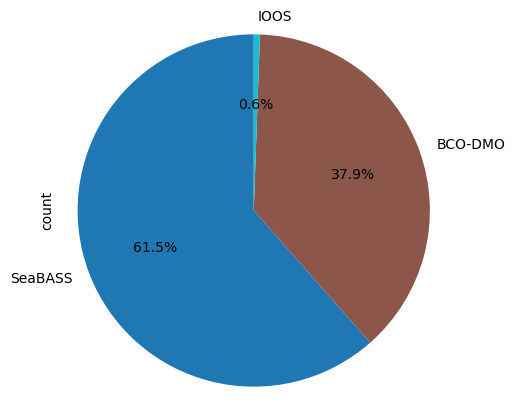

In [4]:
category_counts = cdom['source'].value_counts() 
plt.figure(figsize=(5, 5)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab10')
plt.axis('equal') 
plt.show()

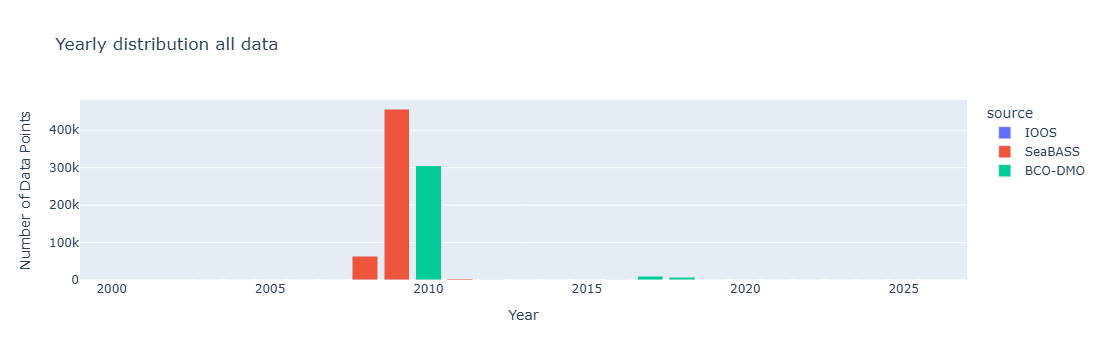

In [5]:
year_test=cdom.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped, x='year', y='DataPoints', color='source', title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

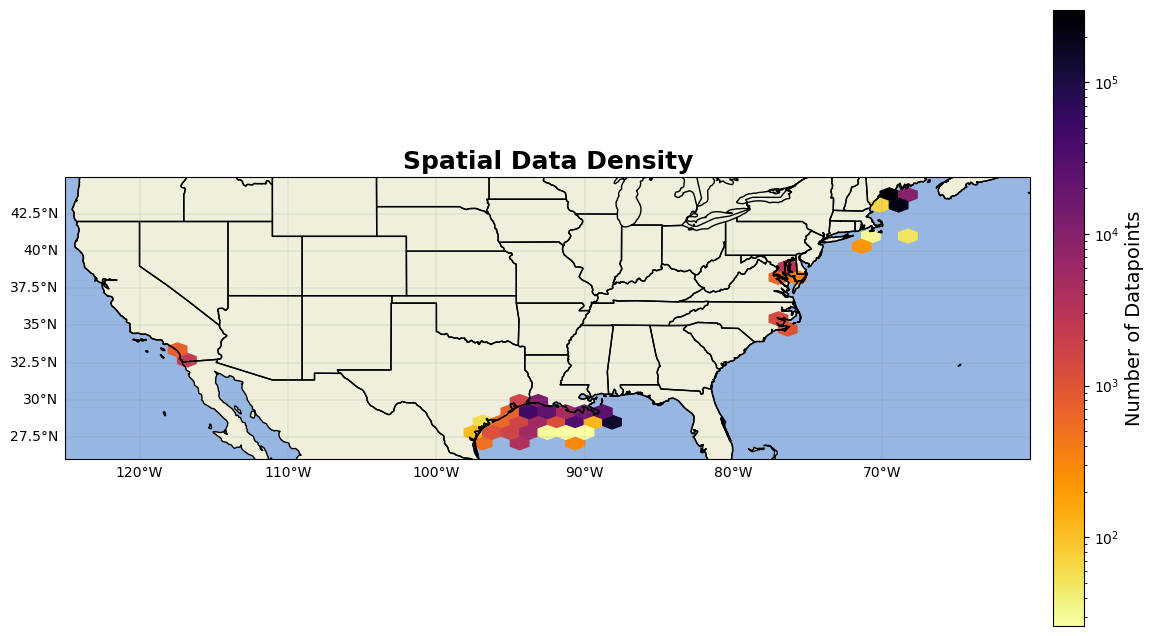

In [13]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(cdom.lon, cdom.lat, gridsize=(40,12), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-125, -60, 26, 45], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()